In [3]:
import pandas as pd

df = pd.read_parquet("../data/reddit_climate_stance_scored.parquet")
df.groupby("subreddit")["stance_score"].agg(["mean", "count"]).sort_values("mean")

,mean,count
subreddit,,
climateskeptics,0.452062,73042
conspiracy,0.514807,243531
politics,0.551762,86339
EverythingScience,0.558122,20650
news,0.568360,51974
Climate_Nuremberg,0.572341,178
changemyview,0.578151,187214
worldnews,0.578556,107716
GlobalClimateChange,0.578657,1064


1881679


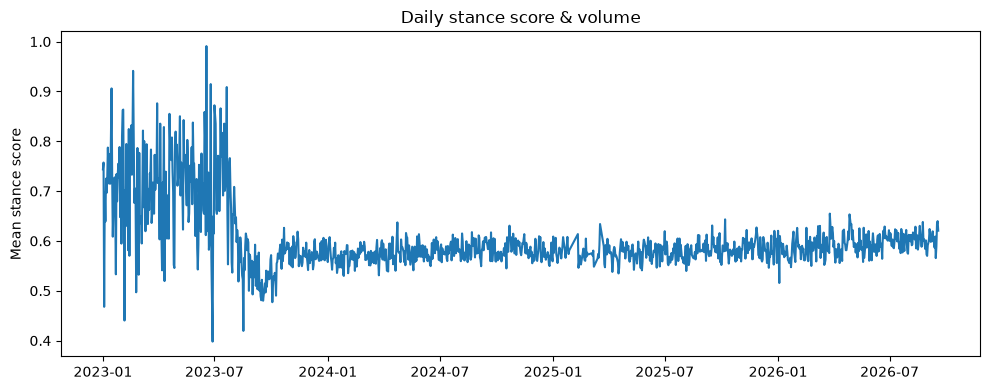

In [23]:
import matplotlib.pyplot as plt

df = df[df["created_time"] >= "2023-01-01"]

daily = df.groupby(df["created_time"].dt.date)["stance_score"].agg(["mean", "count"])
print(len(df))
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(daily.index, daily["mean"])
ax.set_ylabel("Mean stance score")
plt.title("Daily stance score & volume")
plt.tight_layout()
plt.show()

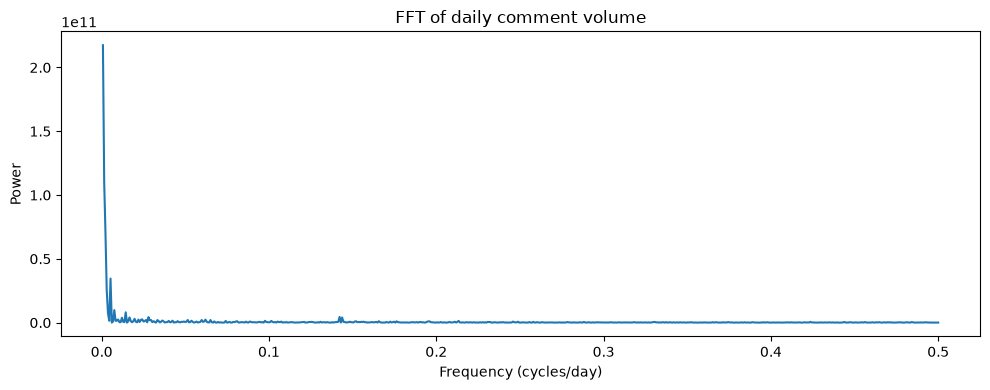

In [3]:
import numpy as np

# use volume (or swap for daily["mean"] to check stance periodicity)
signal = daily["count"].values
signal = signal - signal.mean()  # remove DC component

fft_vals = np.fft.rfft(signal)
freqs = np.fft.rfftfreq(len(signal), d=1)  # d=1 day
    
power = np.abs(fft_vals) ** 2

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(freqs[1:], power[1:])  # skip freq=0
ax.set_xlabel("Frequency (cycles/day)")
ax.set_ylabel("Power")
plt.title("FFT of daily comment volume")
plt.tight_layout()
plt.show()

In [14]:
events=pd.read_excel("../data/climate.xlsx")
print(events.columns.tolist())

['DisNo.', 'Historic', 'Classification Key', 'Disaster Group', 'Disaster Subgroup', 'Disaster Type', 'Disaster Subtype', 'External IDs', 'Event Name', 'ISO', 'Country', 'Subregion', 'Region', 'Location', 'Origin', 'Associated Types', 'OFDA/BHA Response', 'Appeal', 'Declaration', "AID Contribution ('000 US$)", 'Magnitude', 'Magnitude Scale', 'Latitude', 'Longitude', 'River Basin', 'Start Year', 'Start Month', 'Start Day', 'End Year', 'End Month', 'End Day', 'Total Deaths', 'No. Injured', 'No. Affected', 'No. Homeless', 'Total Affected', "Reconstruction Costs ('000 US$)", "Reconstruction Costs, Adjusted ('000 US$)", "Insured Damage ('000 US$)", "Insured Damage, Adjusted ('000 US$)", "Total Damage ('000 US$)", "Total Damage, Adjusted ('000 US$)", 'CPI', 'Admin Units', 'GADM Admin Units', 'Entry Date', 'Last Update']


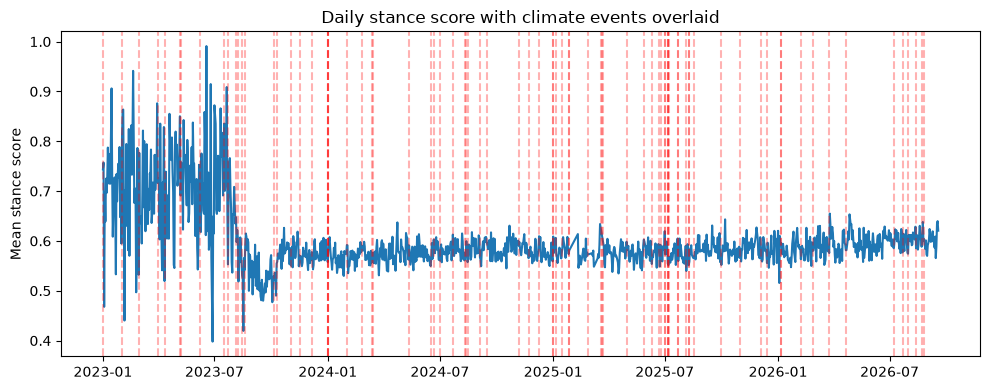

In [27]:
import matplotlib.pyplot as plt

emdat = pd.read_excel("../data/climate.xlsx")
emdat["date"] = pd.to_datetime(
    dict(
        year=emdat["Start Year"],
        month=emdat["Start Month"].fillna(1),
        day=emdat["Start Day"].fillna(1),
    ),
    errors="coerce",
)
emdat = emdat.dropna(subset=["Start Month", "Start Day"])

events = emdat[["date", "Disaster Type", "Country"]].dropna(subset=["date"])
events["event"] = events["Disaster Type"] + " - " + events["Country"]
events = events[["date", "event"]]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(daily.index, daily["mean"])

for d in events["date"]:
    if d.date() >= daily.index.min() and d.date() <= daily.index.max():
        ax.axvline(d, color="red", alpha=0.3, linestyle="--")

ax.set_ylabel("Mean stance score")
plt.title("Daily stance score with climate events overlaid")
plt.tight_layout()
plt.show()

In [29]:
from sklearn.linear_model import LassoCV
cols = {}
for _, row in events.iterrows():
    d = row["date"].date()
    cols[f"{row['event']}_{d}"] = [(1 if 0 <= (day - d).days <= 3 else 0) for day in daily.index]

X = pd.DataFrame(cols, index=daily.index)
X = X.loc[:, X.sum() > 0]

y = daily["mean"]

lasso = LassoCV(cv=5, alphas=np.logspace(-6, 0, 50))
lasso.fit(X, y)

print("Chosen alpha:", lasso.alpha_)
print("R²:", lasso.score(X, y))

coefs = pd.Series(lasso.coef_, index=X.columns)
coefs[coefs != 0].sort_values()

Chosen alpha: 0.00012067926406393288
R²: 0.09300412515545198


Wildfire - France_2023-08-14                             -0.051889
Glacial lake outburst flood - India_2023-10-05           -0.030701
Wildfire - Bolivia (Plurinational State of)_2023-11-17   -0.000286
Wildfire - Republic of Korea_2023-04-11                   0.012380
Drought - China_2023-01-01                                0.027568
Drought - Brazil_2023-03-01                               0.038010
Wildfire - Kazakhstan_2023-06-08                          0.049335
Wildfire - Algeria_2023-07-23                             0.051353
Drought - United States of America_2023-04-01             0.081982
Wildfire - Greece_2023-07-17                              0.113671
Wildfire - Canada_2023-05-06                              0.118550
Wildfire - Chile_2023-02-01                               0.156007
dtype: float64